# 💧 Analyse de la Qualité de l'Eau — Projet Machine Learning

**Dataset :** `waterQuality1.csv`  
**Objectif :** Prédire si l'eau est potable (`is_safe = 1`) ou non (`is_safe = 0`)  
**Modèles :** Random Forest & Support Vector Machine (SVM)

---

## 📦 Partie 1 — Importation des bibliothèques

In [1]:
# Bibliothèques de base
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
#matplotlib inline

# Prétraitement
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# Sélection de features
from sklearn.feature_selection import SelectKBest, f_classif, RFE

# Modèles
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Évaluation
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, f1_score, precision_score, recall_score)

print('✅ Bibliothèques chargées avec succès')

✅ Bibliothèques chargées avec succès


---
## 📊 Partie 2 — Affichage et interprétation des données

In [40]:
# Chargement du dataset
df = pd.read_csv(r"C:\Users\Aymen Ben Youssef\Desktop\Projet FD\water\waterQuality1.csv")

print('=== DIMENSIONS DU DATASET ===')
print(f'Lignes : {df.shape[0]:,} | Colonnes : {df.shape[1]}')

print('\n=== APERÇU DES PREMIÈRES LIGNES ===')
df.head()

=== DIMENSIONS DU DATASET ===
Lignes : 7,999 | Colonnes : 21

=== APERÇU DES PREMIÈRES LIGNES ===


,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [11]:
print('=== INFORMATIONS GÉNÉRALES ===')
df.info()

print('\n=== STATISTIQUES DESCRIPTIVES ===')
df.describe().T.style.background_gradient(cmap='Blues')

=== INFORMATIONS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7997 non-null   float64
 1   ammonia      7998 non-null   object 
 2   arsenic      7995 non-null   float64
 3   barium       7991 non-null   float64
 4   cadmium      7994 non-null   float64
 5   chloramine   7995 non-null   float64
 6   chromium     7993 non-null   float64
 7   copper       7995 non-null   float64
 8   flouride     7996 non-null   float64
 9   bacteria     7995 non-null   float64
 10  viruses      7995 non-null   float64
 11  lead         7997 non-null   float64
 12  nitrates     7983 non-null   float64
 13  nitrites     7994 non-null   float64
 14  mercury      7996 non-null   float64
 15  perchlorate  7994 non-null   float64
 16  radium       7992 non-null   float64
 17  selenium     7997 non-null   float64
 18  silver       7997

,count,mean,std,min,25%,50%,75%,max
aluminium,7997.000000,0.666306,1.265269,0.000000,0.040000,0.070000,0.280000,5.050000
arsenic,7995.000000,0.161503,0.252639,0.000000,0.030000,0.050000,0.100000,1.050000
barium,7991.000000,1.568538,1.216161,0.000000,0.560000,1.190000,2.490000,4.940000
cadmium,7994.000000,0.042797,0.036048,0.000000,0.008000,0.040000,0.070000,0.130000
chloramine,7995.000000,2.177557,2.567326,0.000000,0.100000,0.530000,4.240000,8.680000
chromium,7993.000000,0.247369,0.270688,0.000000,0.050000,0.090000,0.440000,0.900000
copper,7995.000000,0.805784,0.653511,0.000000,0.090000,0.750000,1.390000,2.000000
flouride,7996.000000,0.771623,0.435371,0.000000,0.410000,0.770000,1.160000,1.500000
bacteria,7995.000000,0.319652,0.329524,0.000000,0.000000,0.220000,0.610000,1.000000
viruses,7995.000000,0.328496,0.378100,0.000000,0.002000,0.008000,0.700000,1.000000


In [41]:
print('=== DISTRIBUTION DE LA VARIABLE CIBLE ===')
counts = df['is_safe'].value_counts()
print(counts)
print(f'\nProportion eau potable : {counts[1]/len(df)*100:.1f}%')
print(f'Proportion eau non potable : {counts[0]/len(df)*100:.1f}%')

print('\n=== VALEURS MANQUANTES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Aucune valeur manquante détectée ✅')



=== DISTRIBUTION DE LA VARIABLE CIBLE ===
is_safe
0    7087
1     912
Name: count, dtype: int64

Proportion eau potable : 11.4%
Proportion eau non potable : 88.6%

=== VALEURS MANQUANTES ===
aluminium       2
ammonia         4
arsenic         4
barium          8
cadmium         5
chloramine      4
chromium        6
copper          4
flouride        3
bacteria        4
viruses         4
lead            2
nitrates       16
nitrites        5
mercury         3
perchlorate     5
radium          7
selenium        2
silver          2
uranium         3
dtype: int64


### 📝 Interprétation

Le dataset `waterQuality1.csv` contient **8 000 échantillons** d'eau décrits par **20 caractéristiques chimiques** :

| Groupe | Caractéristiques |
|--------|------------------|
| Métaux lourds | aluminium, arsenic, barium, cadmium, chromium, copper, lead, mercury, silver |
| Composés azotés | ammonia, nitrates, nitrites |
| Autres contaminants | chloramine, flouride, bacteria, viruses, perchlorate, radium, selenium, uranium |

La **variable cible** `is_safe` est binaire : `1` = eau potable, `0` = eau non potable.

---
## 📈 Partie 3 — Visualisation des données (Seaborn)

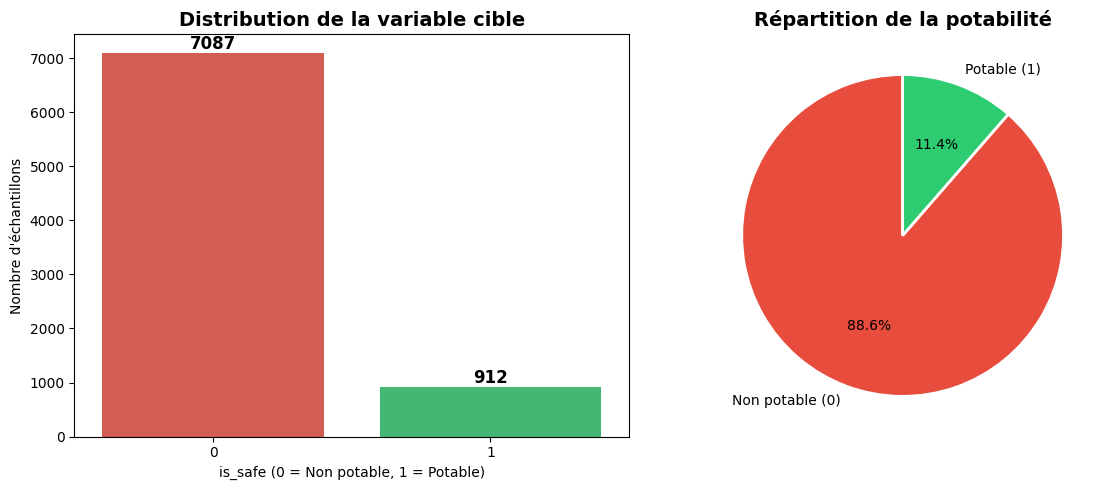

In [43]:
# 3.1 — Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
sns.countplot(data=df, x='is_safe', palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Distribution de la variable cible', fontsize=14, fontweight='bold')
axes[0].set_xlabel('is_safe (0 = Non potable, 1 = Potable)')
axes[0].set_ylabel('Nombre d\'échantillons')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
counts = df['is_safe'].value_counts()
labels = ['Non potable (0)', 'Potable (1)']
colors = ['#e74c3c', '#2ecc71']
axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition de la potabilité', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

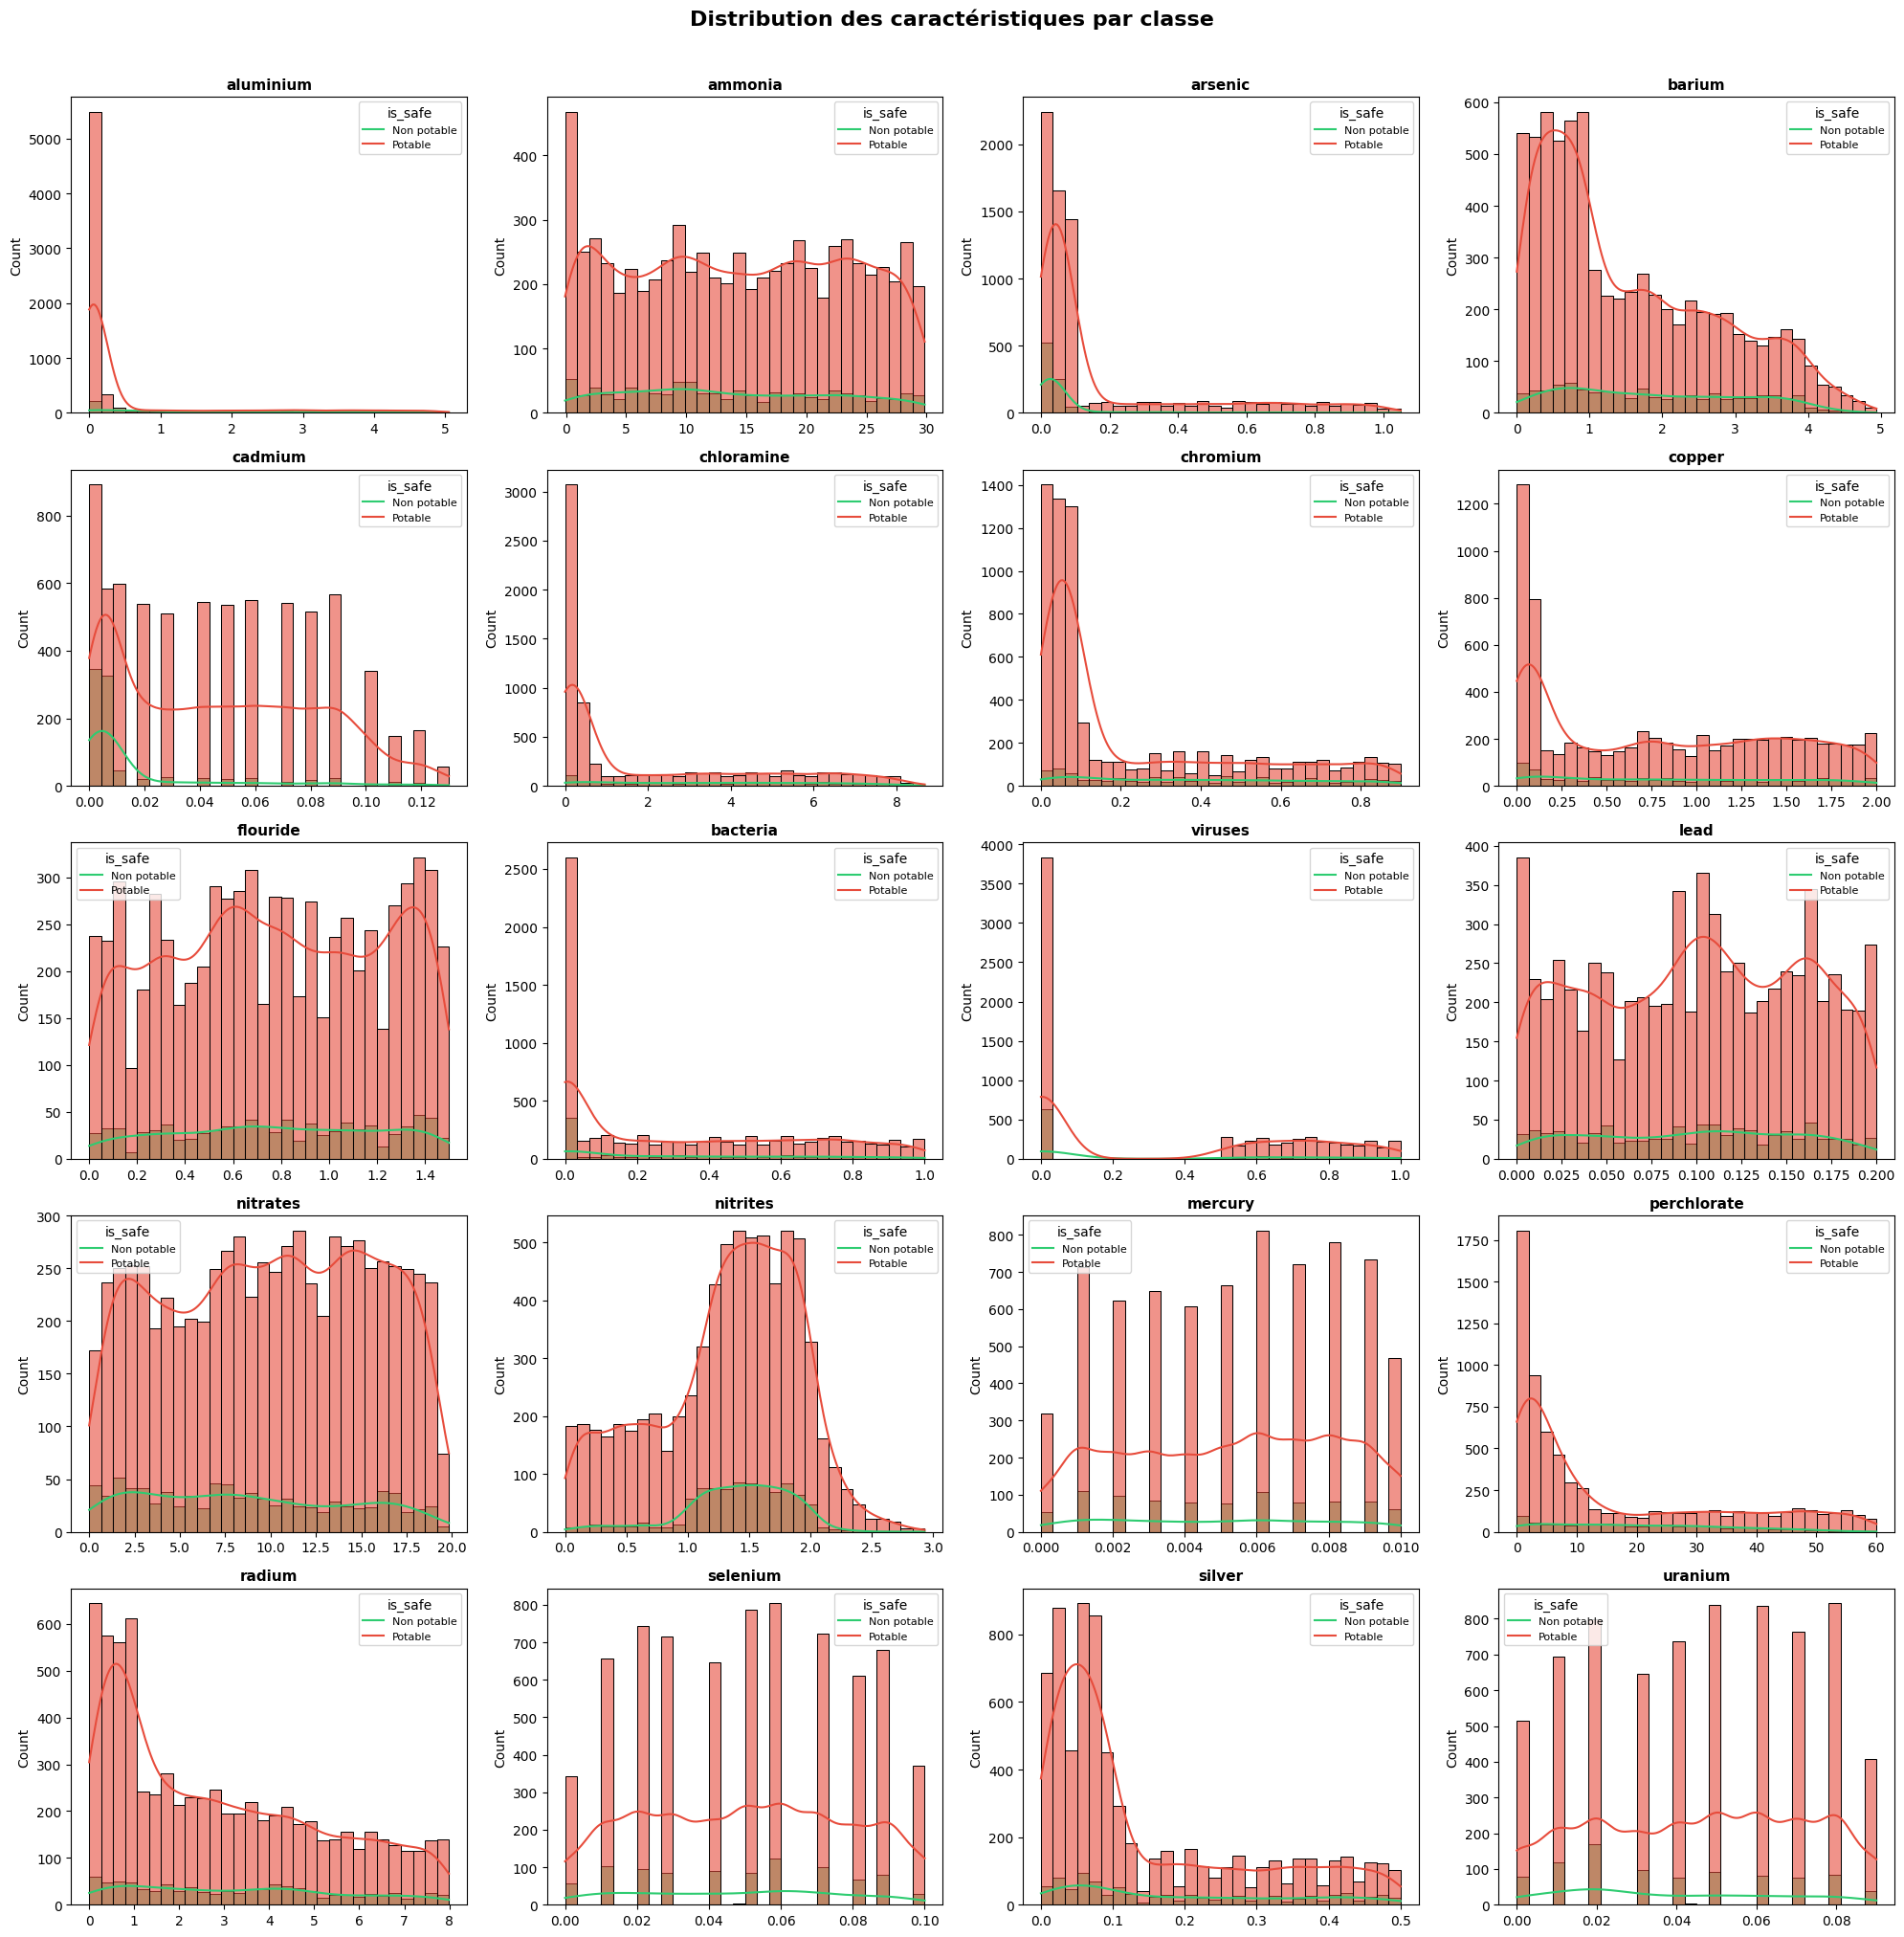

In [44]:
# 3.2 — Distribution de chaque feature (histogrammes + KDE)
features = [c for c in df.columns if c != 'is_safe']
n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.histplot(data=df, x=feat, hue='is_safe', kde=True, ax=axes[i],
                 palette={'0': '#e74c3c', '1': '#2ecc71'}, alpha=0.6, bins=30)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='is_safe', labels=['Non potable', 'Potable'], fontsize=8)

# Masquer les axes inutilisés
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution des caractéristiques par classe', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

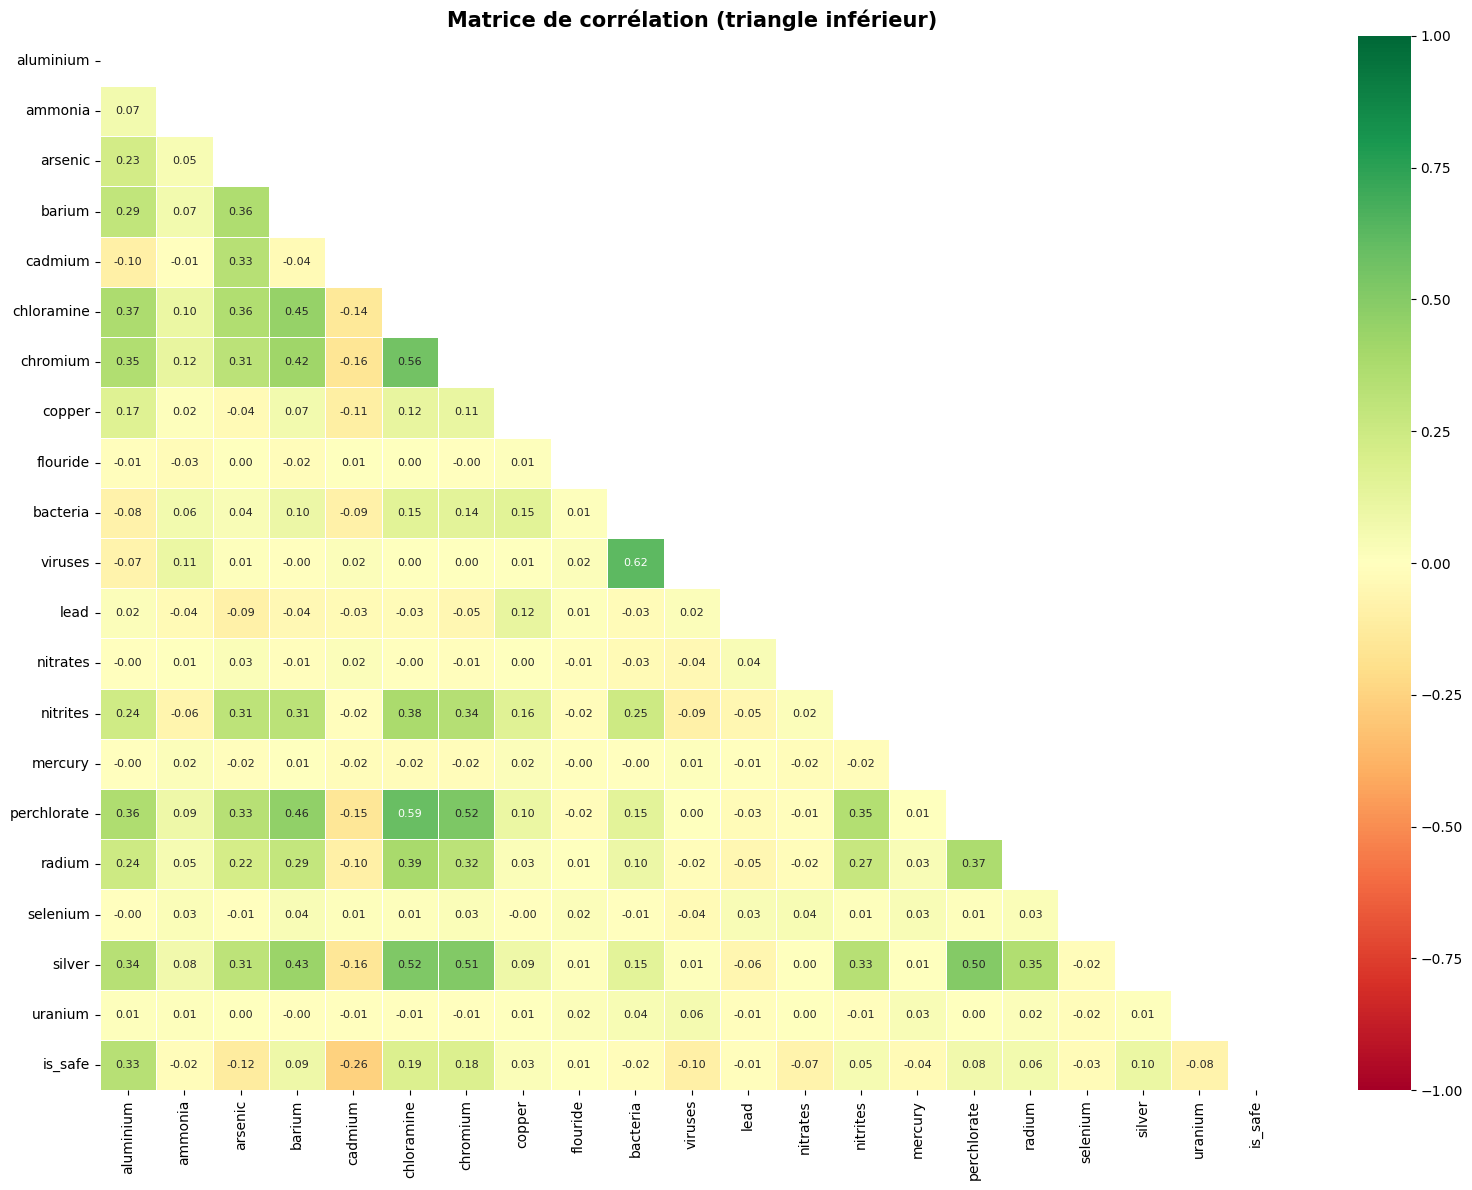

In [45]:
# 3.3 — Matrice de corrélation
fig, ax = plt.subplots(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation (triangle inférieur)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

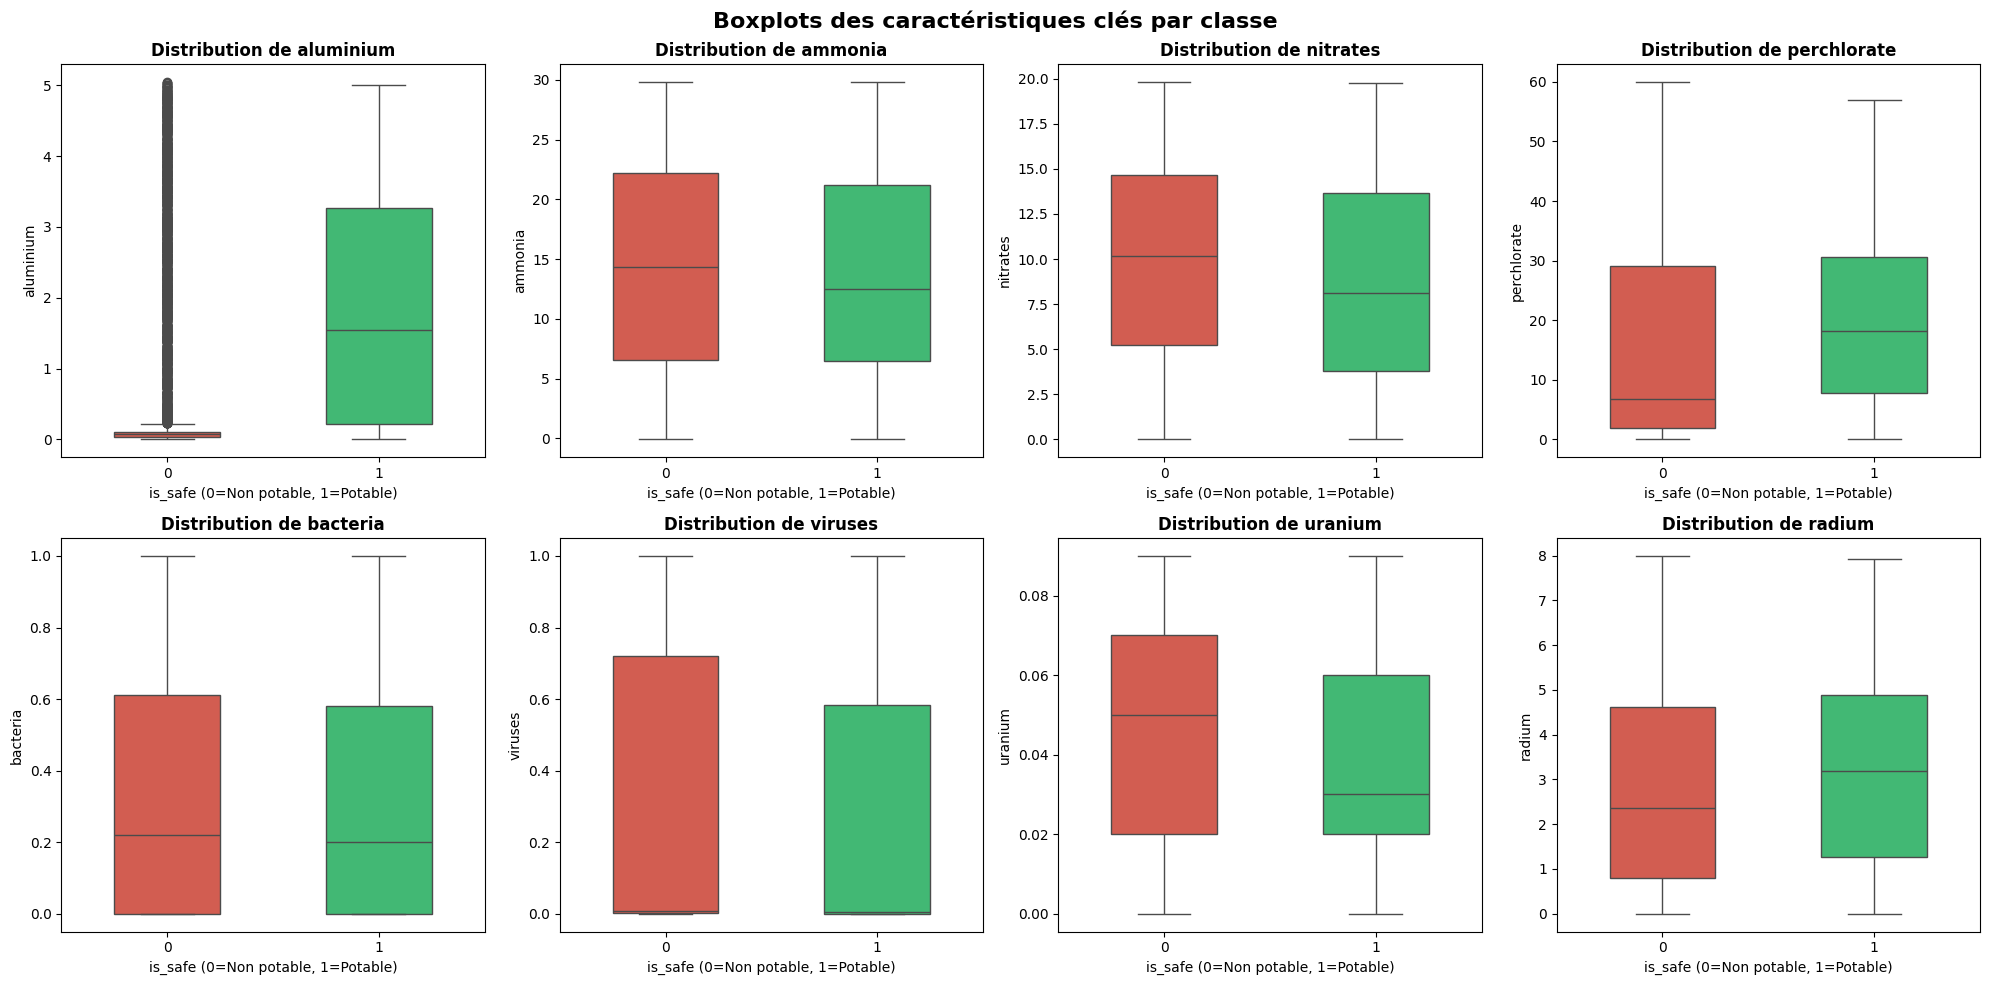

In [47]:
# 3.4 — Boxplots par classe pour les features les plus importantes
key_features = ['aluminium', 'ammonia', 'nitrates', 'perchlorate', 
                'bacteria', 'viruses', 'uranium', 'radium']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='is_safe', y=feat, palette={'0': '#e74c3c', '1': '#2ecc71'},
                ax=axes[i], width=0.5)
    axes[i].set_title(f'Distribution de {feat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('is_safe (0=Non potable, 1=Potable)')

fig.suptitle('Boxplots des caractéristiques clés par classe', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

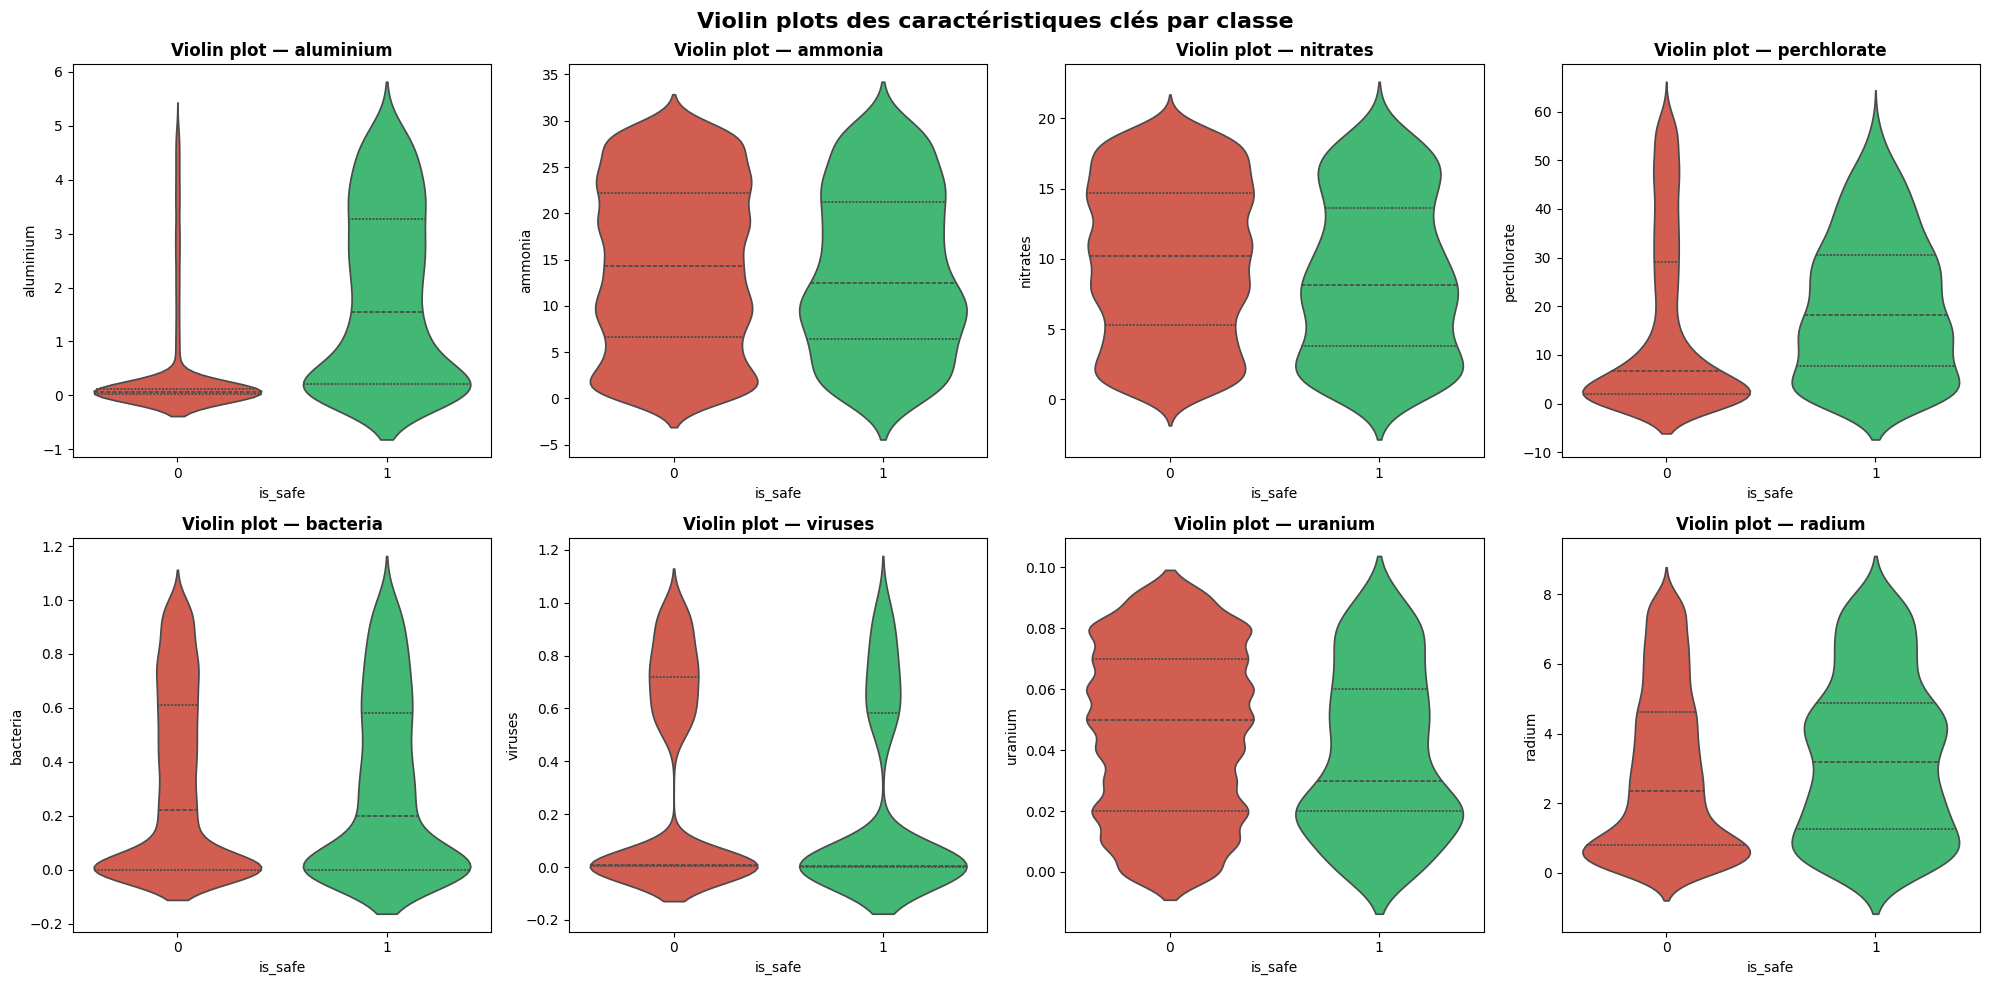

In [48]:
# 3.5 — Violin plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.violinplot(data=df, x='is_safe', y=feat, palette={'0': '#e74c3c', '1': '#2ecc71'},
                   ax=axes[i], inner='quartile')
    axes[i].set_title(f'Violin plot — {feat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('is_safe')

fig.suptitle('Violin plots des caractéristiques clés par classe', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

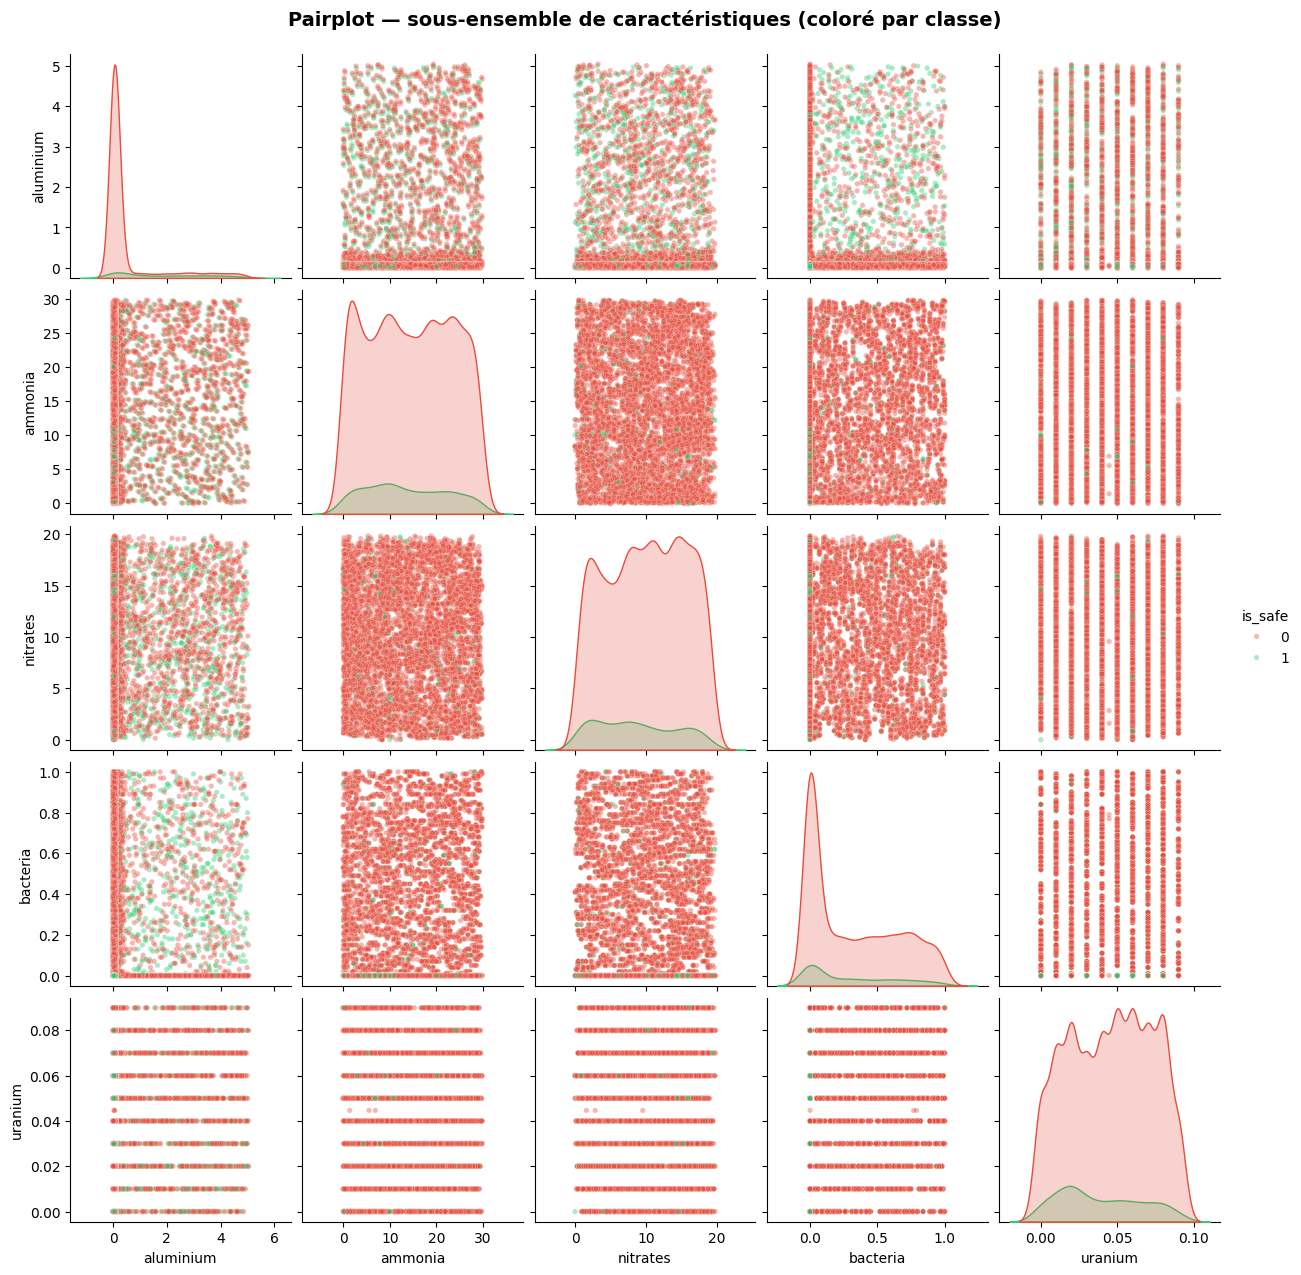

In [50]:
# 3.6 — Pairplot sur un sous-ensemble de features
pair_features = ['aluminium', 'ammonia', 'nitrates', 'bacteria', 'uranium', 'is_safe']
g = sns.pairplot(df[pair_features], hue='is_safe', palette={0: '#e74c3c', 1: '#2ecc71'},
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
g.fig.suptitle('Pairplot — sous-ensemble de caractéristiques (coloré par classe)',
               y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 🔍 Partie 4 — Détection des valeurs aberrantes

In [51]:
# 4.1 — Méthode IQR (Interquartile Range)
print('=== DÉTECTION DES VALEURS ABERRANTES (Méthode IQR) ===')

outlier_summary = []
X_features = [c for c in df.columns if c != 'is_safe']

for col in X_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    outlier_summary.append({'Feature': col, 'Q1': round(Q1, 4), 'Q3': round(Q3, 4),
                             'IQR': round(IQR, 4), 'Borne inf': round(lower, 4),
                             'Borne sup': round(upper, 4),
                             'Nb aberrants': n_out, '% aberrants': round(pct, 2)})

outlier_df = pd.DataFrame(outlier_summary).set_index('Feature')
outlier_df.sort_values('% aberrants', ascending=False)

=== DÉTECTION DES VALEURS ABERRANTES (Méthode IQR) ===


,Q1,Q3,IQR,Borne inf,Borne sup,Nb aberrants,% aberrants
Feature,,,,,,,
aluminium,0.040,0.280,0.240,-0.3200,0.6400,1733,21.67
arsenic,0.030,0.100,0.070,-0.0750,0.2050,1634,20.43
nitrites,1.000,1.760,0.760,-0.1400,2.9000,2,0.03
ammonia,6.580,22.130,15.550,-16.7450,45.4550,0,0.00
barium,0.560,2.480,1.920,-2.3200,5.3600,0,0.00
cadmium,0.008,0.070,0.062,-0.0850,0.1630,0,0.00
chromium,0.050,0.440,0.390,-0.5350,1.0250,0,0.00
chloramine,0.100,4.240,4.140,-6.1100,10.4500,0,0.00
flouride,0.410,1.160,0.750,-0.7150,2.2850,0,0.00


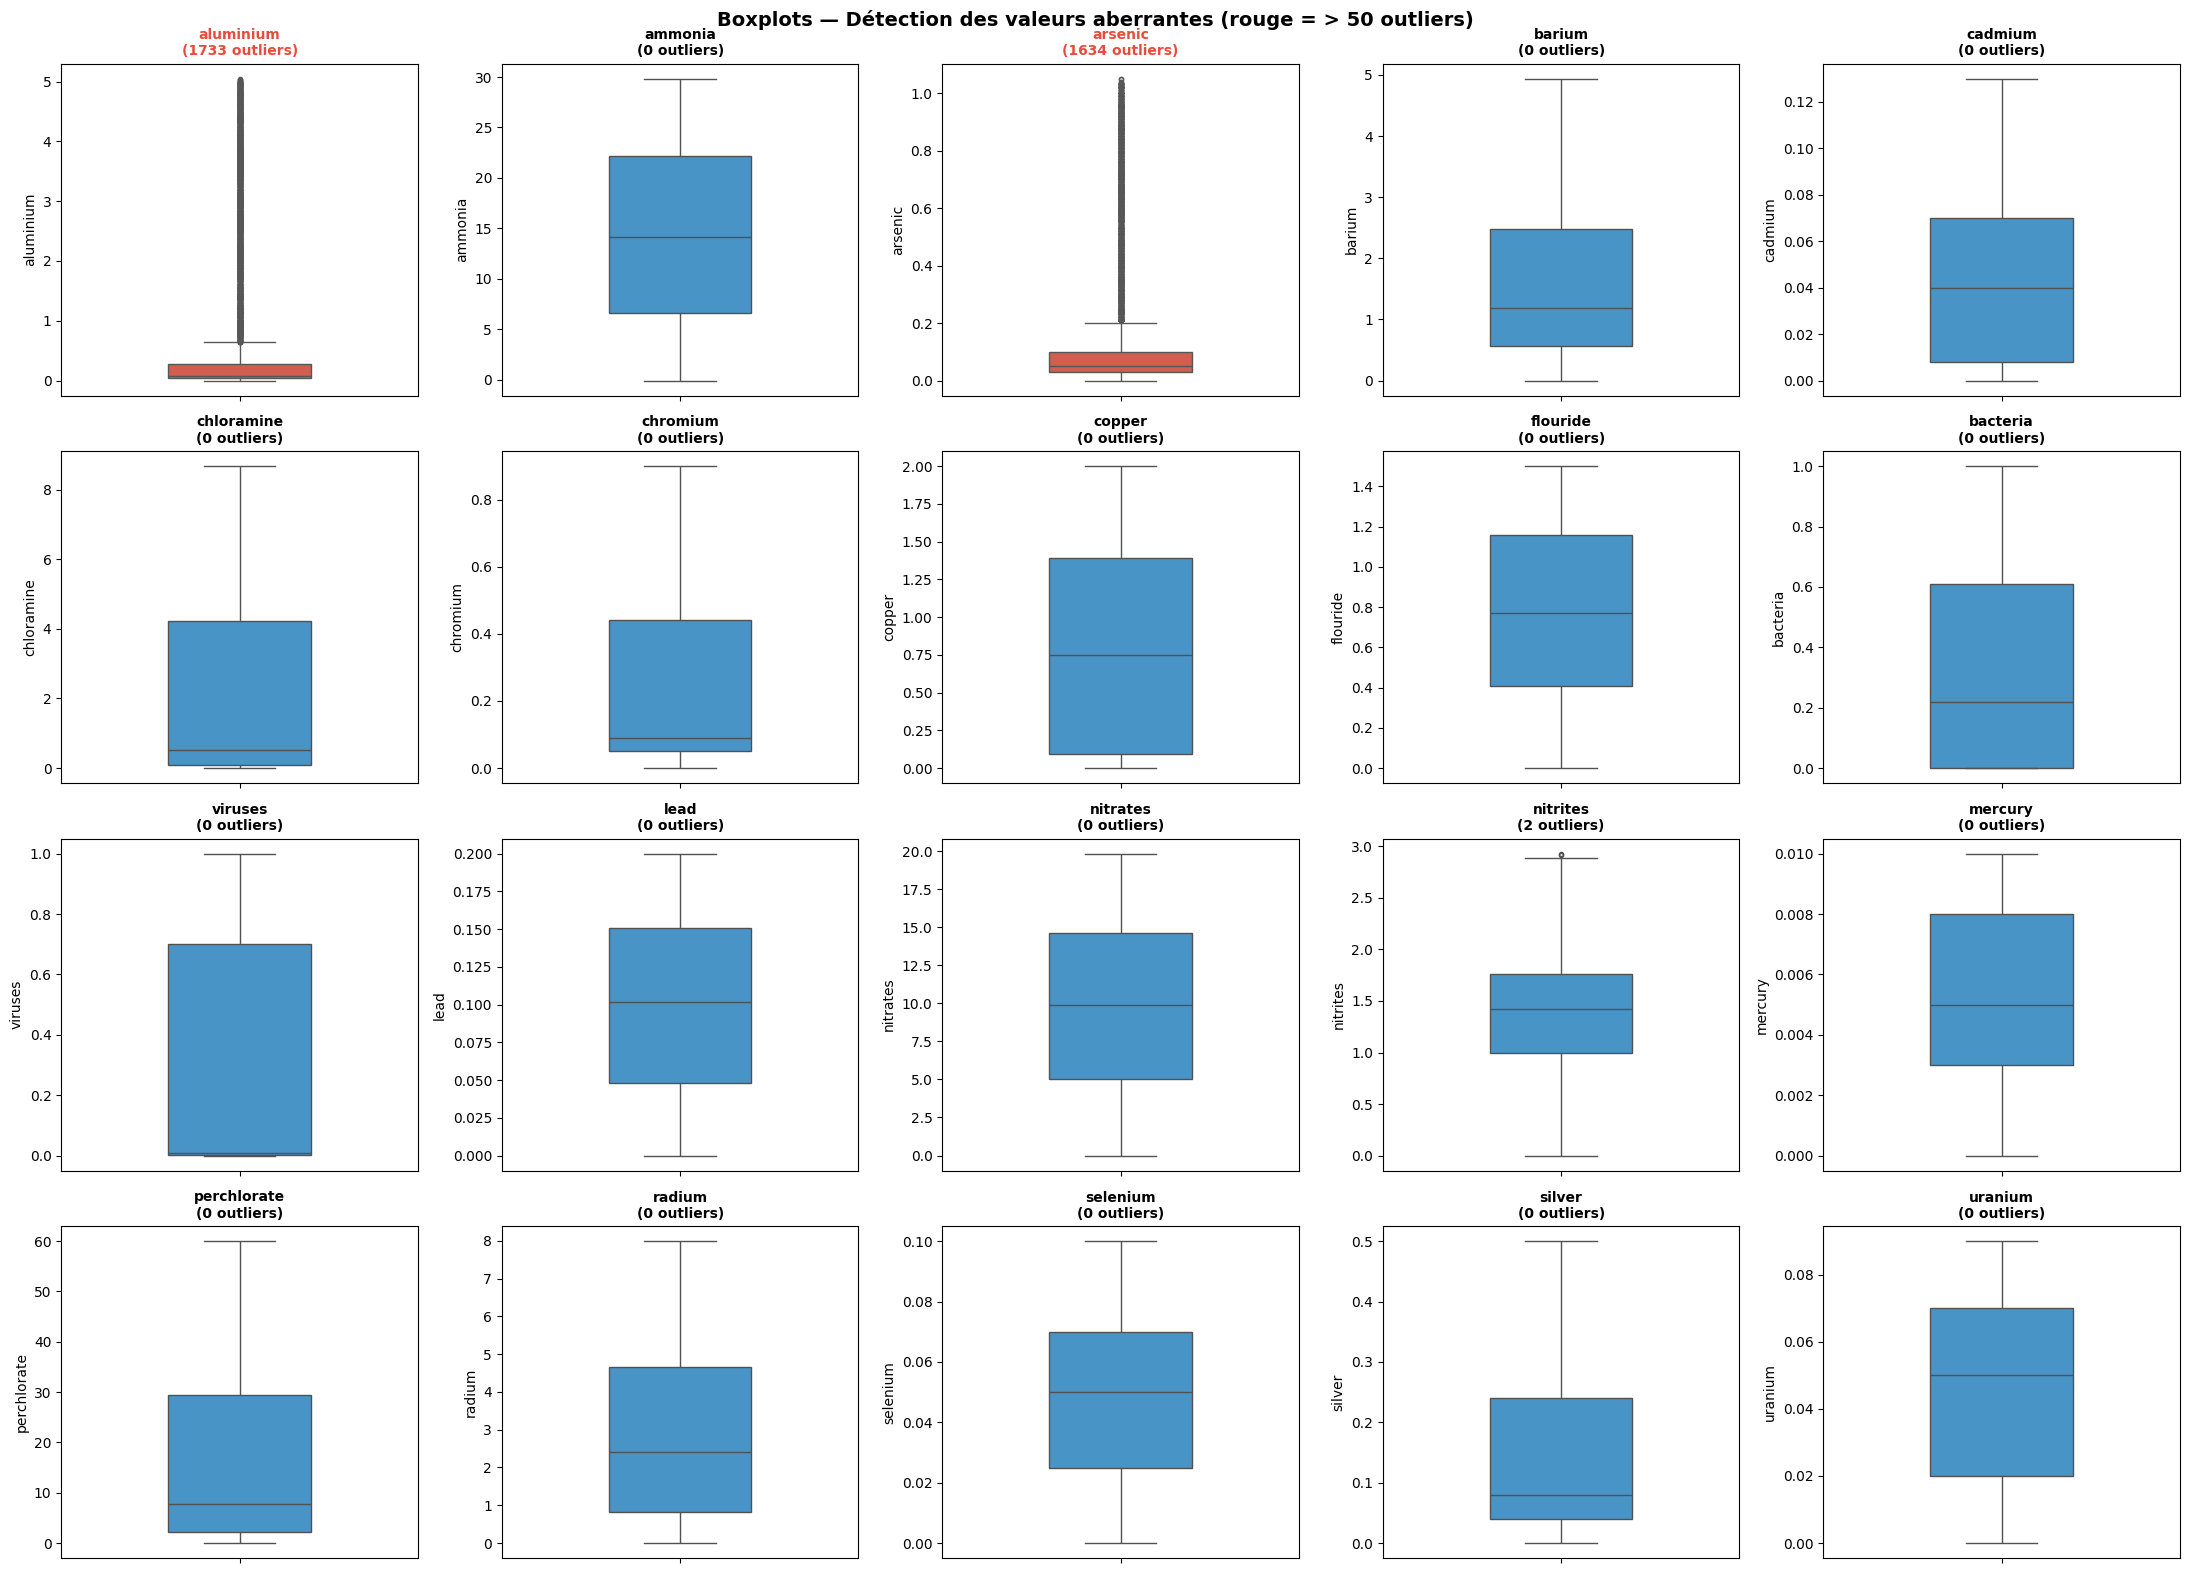

In [52]:
# 4.2 — Visualisation des outliers (boxplots sur toutes les features)
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for i, col in enumerate(X_features):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    
    color = '#e74c3c' if n_out > 50 else '#3498db'
    sns.boxplot(y=df[col], ax=axes[i], color=color, width=0.4, flierprops={'markersize': 3})
    axes[i].set_title(f'{col}\n({n_out} outliers)', fontsize=10, fontweight='bold',
                      color='#e74c3c' if n_out > 50 else 'black')

plt.suptitle('Boxplots — Détection des valeurs aberrantes (rouge = > 50 outliers)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== DÉTECTION PAR Z-SCORE (|Z| > 3) ===
             Outliers Z>3
arsenic               205
aluminium             186
ammonia                 0
barium                  0
cadmium                 0
chloramine              0
chromium                0
copper                  0
flouride                0
bacteria                0
viruses                 0
lead                    0
nitrates                0
nitrites                0
mercury                 0
perchlorate             0
radium                  0
selenium                0
silver                  0
uranium                 0


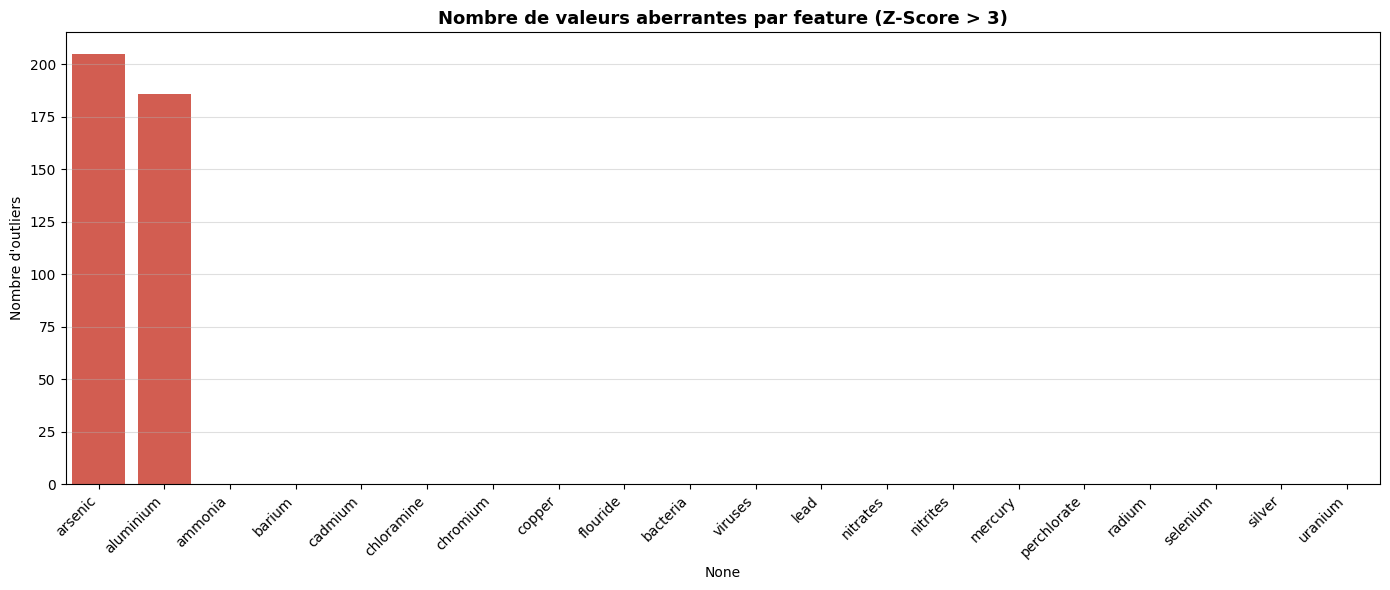

In [53]:
# 4.3 — Méthode Z-Score
from scipy import stats

print('=== DÉTECTION PAR Z-SCORE (|Z| > 3) ===')
zscore_out = {}
for col in X_features:
    z = np.abs(stats.zscore(df[col].dropna()))
    n_out = (z > 3).sum()
    zscore_out[col] = n_out

zscore_df = pd.DataFrame.from_dict(zscore_out, orient='index', columns=['Outliers Z>3'])
zscore_df = zscore_df.sort_values('Outliers Z>3', ascending=False)
print(zscore_df)

# Visualisation
plt.figure(figsize=(14, 6))
sns.barplot(x=zscore_df.index, y=zscore_df['Outliers Z>3'],
            palette=['#e74c3c' if v > 20 else '#3498db' for v in zscore_df['Outliers Z>3']])
plt.xticks(rotation=45, ha='right')
plt.title('Nombre de valeurs aberrantes par feature (Z-Score > 3)', fontsize=13, fontweight='bold')
plt.ylabel('Nombre d\'outliers')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## ⚙️ Partie 5 — Pré-traitement du jeu de données

In [54]:
# 5.1 — Nettoyage des données
df_clean = df.copy()

# Suppression des doublons
n_before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
n_after = len(df_clean)
print(f'Doublons supprimés : {n_before - n_after}')
print(f'Taille finale : {n_after:,} lignes')

# Traitement des valeurs manquantes (imputation par médiane si nécessaire)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  Colonne {col}: {df_clean[col].isnull().sum()} NaN → imputés par médiane ({median_val:.4f})')

print('\n✅ Traitement des valeurs manquantes terminé')

Doublons supprimés : 0
Taille finale : 7,999 lignes

✅ Traitement des valeurs manquantes terminé


✅ Winsorization appliquée : 3,369 valeurs caps au total


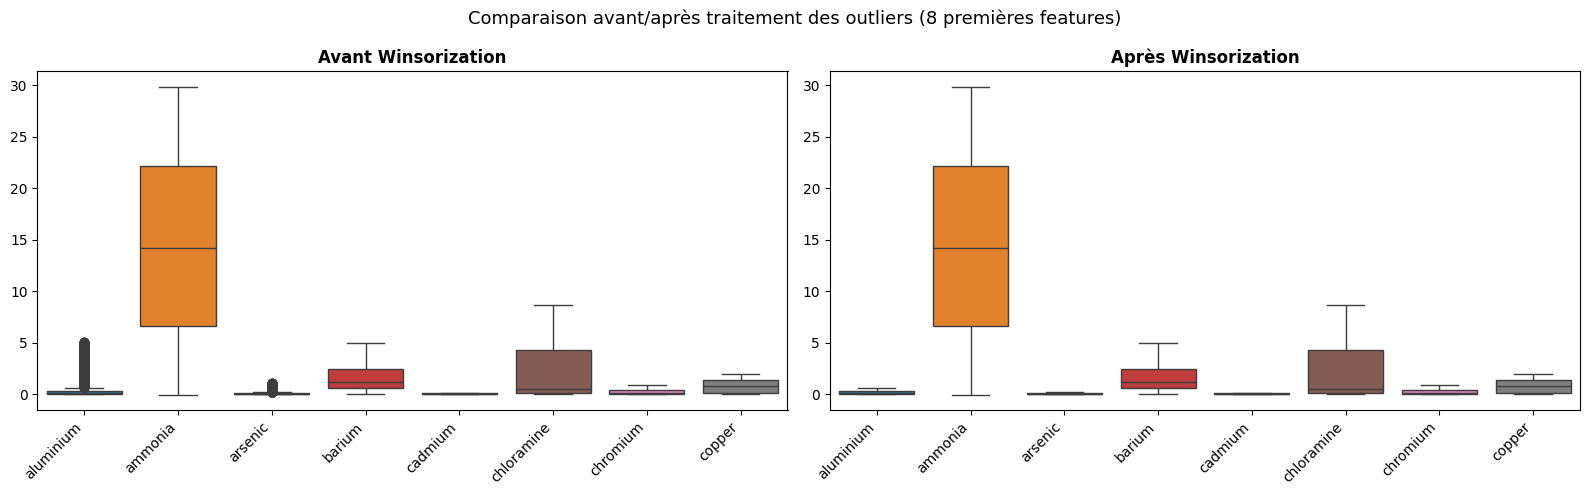

In [55]:
# 5.2 — Traitement des valeurs aberrantes (Winsorization = capping à 1.5xIQR)
df_clean2 = df_clean.copy()
X_features = [c for c in df_clean2.columns if c != 'is_safe']

capped_count = 0
for col in X_features:
    Q1 = df_clean2[col].quantile(0.25)
    Q3 = df_clean2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean2[col] < lower) | (df_clean2[col] > upper)).sum()
    df_clean2[col] = df_clean2[col].clip(lower, upper)
    capped_count += n_out

print(f'✅ Winsorization appliquée : {capped_count:,} valeurs caps au total')

# Comparaison avant/après
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df_clean[X_features[:8]], ax=axes[0])
axes[0].set_title('Avant Winsorization', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
sns.boxplot(data=df_clean2[X_features[:8]], ax=axes[1])
axes[1].set_title('Après Winsorization', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.suptitle('Comparaison avant/après traitement des outliers (8 premières features)', fontsize=13)
plt.tight_layout()
plt.show()

In [56]:
# 5.3 — Séparation X / y et normalisation
X = df_clean2.drop('is_safe', axis=1)
y = df_clean2['is_safe']

# Normalisation (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Distribution après normalisation (StandardScaler) :')
print(X_scaled_df.describe().T[['mean', 'std']].round(4))

Distribution après normalisation (StandardScaler) :
             mean     std
aluminium    -0.0  1.0001
ammonia      -0.0  1.0001
arsenic      -0.0  1.0001
barium        0.0  1.0001
cadmium      -0.0  1.0001
chloramine   -0.0  1.0001
chromium      0.0  1.0001
copper        0.0  1.0001
flouride      0.0  1.0001
bacteria      0.0  1.0001
viruses      -0.0  1.0001
lead          0.0  1.0001
nitrates     -0.0  1.0001
nitrites     -0.0  1.0001
mercury      -0.0  1.0001
perchlorate  -0.0  1.0001
radium       -0.0  1.0001
selenium     -0.0  1.0001
silver        0.0  1.0001
uranium      -0.0  1.0001


In [57]:
# 5.4 — Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('=== RÉPARTITION TRAIN / TEST ===')
print(f'Train : {X_train.shape[0]:,} échantillons — Test : {X_test.shape[0]:,} échantillons')
print(f'\nDistribution train :\n{pd.Series(y_train).value_counts().rename({0:"Non potable",1:"Potable"})}')
print(f'\nDistribution test :\n{pd.Series(y_test).value_counts().rename({0:"Non potable",1:"Potable"})}')

=== RÉPARTITION TRAIN / TEST ===
Train : 6,399 échantillons — Test : 1,600 échantillons

Distribution train :
is_safe
Non potable    5669
Potable         730
Name: count, dtype: int64

Distribution test :
is_safe
Non potable    1418
Potable         182
Name: count, dtype: int64


---
## 🎯 Partie 6 — Sélection des caractéristiques

=== SCORES ANOVA F (Importance des features) ===
    Feature     F-Score       p-value
  aluminium 1177.824328 4.414899e-237
    cadmium  468.517481 2.493833e-100
   chromium  232.031817  1.707012e-51
 chloramine  224.124348  7.896129e-50
    arsenic  194.756848  1.263497e-43
     silver   63.711500  1.694588e-15
    viruses   57.299371  4.270771e-14
     barium   53.079090  3.589278e-13
    uranium   45.523090  1.640884e-11
   nitrates   44.872445  2.282188e-11
perchlorate   38.944906  4.638370e-10
     radium   22.665381  1.970539e-06
    mercury   12.368680  4.396250e-04
   nitrites   12.015438  5.310844e-04
     copper    7.778640  5.302390e-03
   selenium    6.220357  1.265401e-02
    ammonia    4.362159  3.678513e-02
   bacteria    2.781444  9.541111e-02
   flouride    0.485136  4.861303e-01
       lead    0.086890  7.681779e-01


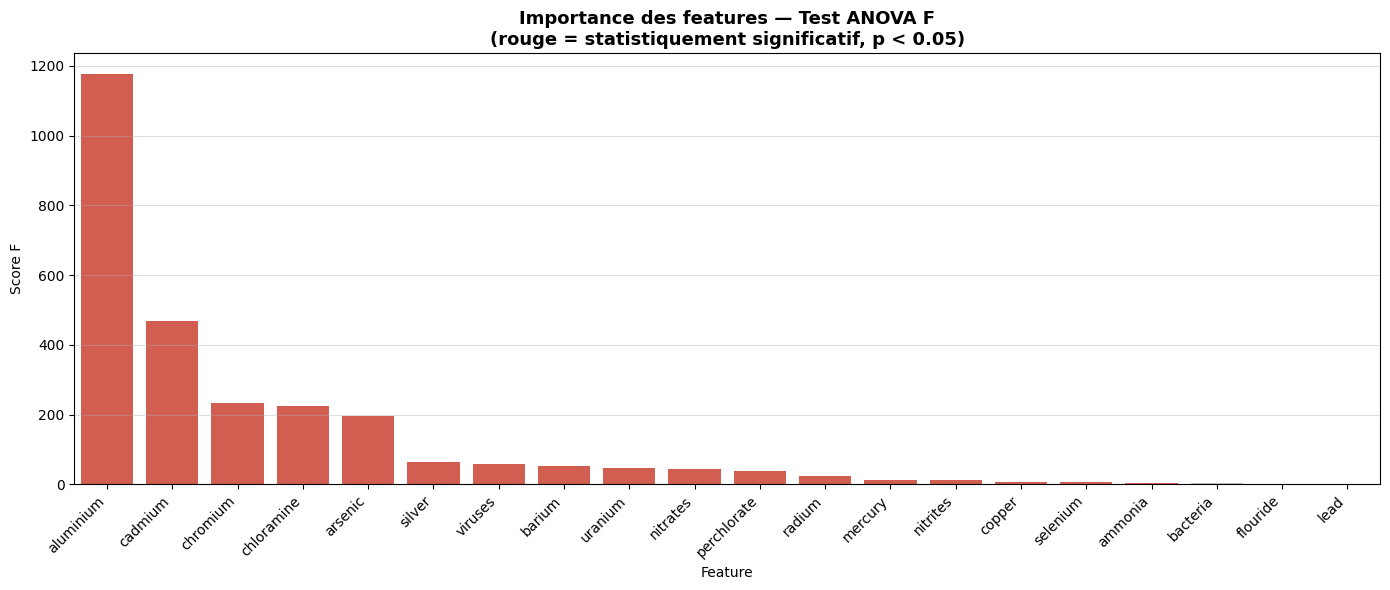

In [58]:
# 6.1 — Test ANOVA F (SelectKBest)
selector_kbest = SelectKBest(score_func=f_classif, k='all')
selector_kbest.fit(X_train, y_train)

feat_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector_kbest.scores_,
    'p-value': selector_kbest.pvalues_
}).sort_values('F-Score', ascending=False)

print('=== SCORES ANOVA F (Importance des features) ===')
print(feat_scores.to_string(index=False))

# Visualisation
plt.figure(figsize=(14, 6))
colors = ['#e74c3c' if p < 0.05 else '#bdc3c7' for p in feat_scores['p-value']]
sns.barplot(x='Feature', y='F-Score', data=feat_scores, palette=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Importance des features — Test ANOVA F\n(rouge = statistiquement significatif, p < 0.05)',
          fontsize=13, fontweight='bold')
plt.ylabel('Score F')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

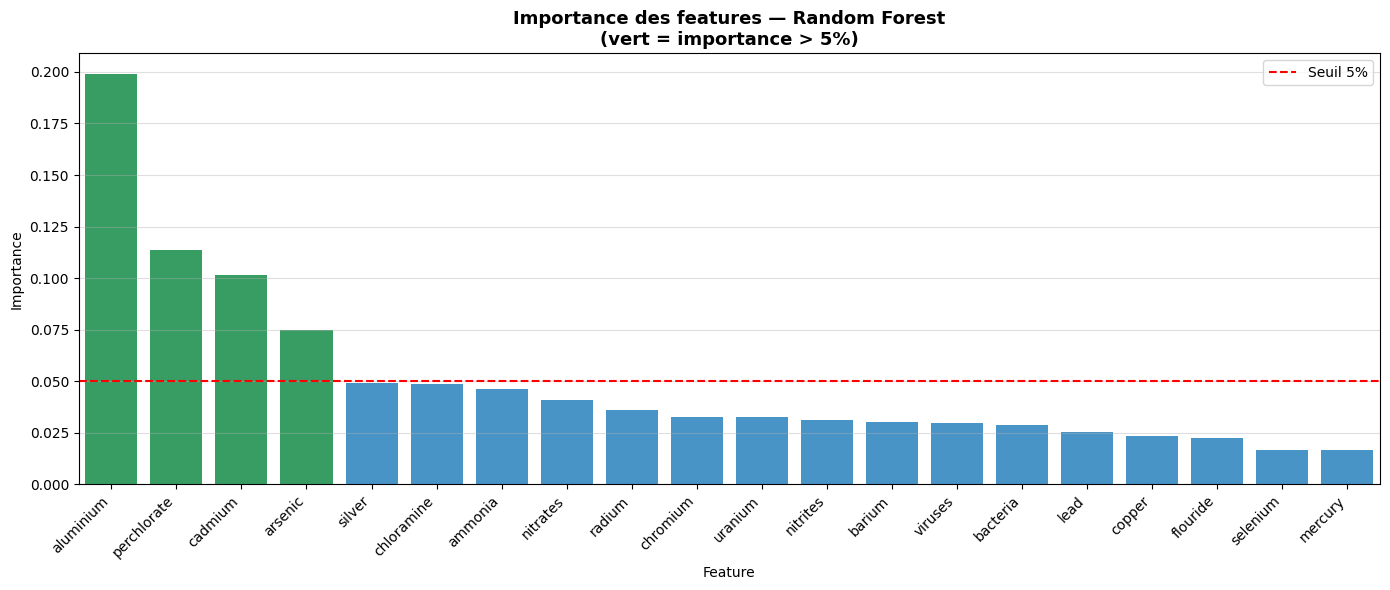


Top 10 features les plus importantes :
    Feature  Importance RF
  aluminium       0.199171
perchlorate       0.113571
    cadmium       0.101743
    arsenic       0.074692
     silver       0.049292
 chloramine       0.048482
    ammonia       0.046334
   nitrates       0.041111
     radium       0.036111
   chromium       0.032766


In [59]:
# 6.2 — Importance des features via Random Forest
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_train, y_train)

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance RF': rf_temp.feature_importances_
}).sort_values('Importance RF', ascending=False)

plt.figure(figsize=(14, 6))
colors_rf = ['#27ae60' if imp > 0.05 else '#3498db' for imp in feat_imp['Importance RF']]
sns.barplot(x='Feature', y='Importance RF', data=feat_imp, palette=colors_rf)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0.05, color='red', linestyle='--', label='Seuil 5%')
plt.title('Importance des features — Random Forest\n(vert = importance > 5%)', fontsize=13, fontweight='bold')
plt.ylabel('Importance')
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print('\nTop 10 features les plus importantes :')
print(feat_imp.head(10).to_string(index=False))

In [60]:
# 6.3 — Sélection finale des features
# On sélectionne les 15 meilleures features par ANOVA F
K_BEST = 15
selector_final = SelectKBest(score_func=f_classif, k=K_BEST)
X_train_sel = selector_final.fit_transform(X_train, y_train)
X_test_sel  = selector_final.transform(X_test)

selected_features = X.columns[selector_final.get_support()].tolist()
print(f'✅ {K_BEST} features sélectionnées :')
for i, f in enumerate(selected_features, 1):
    print(f'  {i:2d}. {f}')

✅ 15 features sélectionnées :
   1. aluminium
   2. arsenic
   3. barium
   4. cadmium
   5. chloramine
   6. chromium
   7. copper
   8. viruses
   9. nitrates
  10. nitrites
  11. mercury
  12. perchlorate
  13. radium
  14. silver
  15. uranium


---
## 🌳 Partie 7 — Modèle 1 : Random Forest

### Description du modèle

Le **Random Forest (Forêt Aléatoire)** est un algorithme d'**ensemble learning** basé sur la combinaison de multiples arbres de décision. Il fonctionne en trois étapes principales :

1. **Bootstrap** : création de N sous-ensembles aléatoires du dataset d'entraînement (tirage avec remise).
2. **Arbres de décision** : entraînement d'un arbre sur chaque sous-ensemble, avec à chaque nœud un sous-ensemble aléatoire de features à évaluer.
3. **Vote majoritaire** : la classe finale est déterminée par le vote de tous les arbres.

```
Dataset original
       │
  ┌────┴────┐
  Bootstrap  Bootstrap ... Bootstrap
  │           │              │
Arbre 1    Arbre 2 ...   Arbre N
  └────┬────┘
  Vote majoritaire (classification)
       │
  Prédiction finale
```

**Avantages** : Robuste aux outliers, peu sujet au sur-apprentissage, fournit les importances de features.  
**Hyperparamètres clés** : `n_estimators`, `max_depth`, `min_samples_split`, `max_features`.

In [61]:
# 7.1 — Optimisation des hyperparamètres par GridSearchCV (CV=4)
print('=== RANDOM FOREST — RECHERCHE DES HYPERPARAMÈTRES OPTIMAUX (CV=4) ===')

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_sel, y_train)

print(f'\n✅ Meilleurs paramètres RF : {grid_rf.best_params_}')
print(f'   Meilleur F1-score (CV) : {grid_rf.best_score_:.4f}')

=== RANDOM FOREST — RECHERCHE DES HYPERPARAMÈTRES OPTIMAUX (CV=4) ===
Fitting 4 folds for each of 24 candidates, totalling 96 fits

✅ Meilleurs paramètres RF : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
   Meilleur F1-score (CV) : 0.7336


In [62]:
# 7.2 — Évaluation du meilleur modèle RF
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_sel)
y_proba_rf = best_rf.predict_proba(X_test_sel)[:, 1]

print('=== PERFORMANCES DU RANDOM FOREST (MEILLEURS PARAMS) ===')
print(classification_report(y_test, y_pred_rf, target_names=['Non potable', 'Potable']))

print(f'AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}')

# Validation croisée finale
cv_scores_rf = cross_val_score(best_rf, X_train_sel, y_train, cv=cv, scoring='f1')
print(f'\nCV F1-scores (4-fold) : {cv_scores_rf.round(4)}')
print(f'Moyenne CV F1         : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

=== PERFORMANCES DU RANDOM FOREST (MEILLEURS PARAMS) ===
              precision    recall  f1-score   support

 Non potable       0.95      0.99      0.97      1418
     Potable       0.88      0.62      0.73       182

    accuracy                           0.95      1600
   macro avg       0.91      0.80      0.85      1600
weighted avg       0.94      0.95      0.94      1600

AUC-ROC : 0.9663

CV F1-scores (4-fold) : [0.7325 0.729  0.7379 0.7348]
Moyenne CV F1         : 0.7336 ± 0.0032


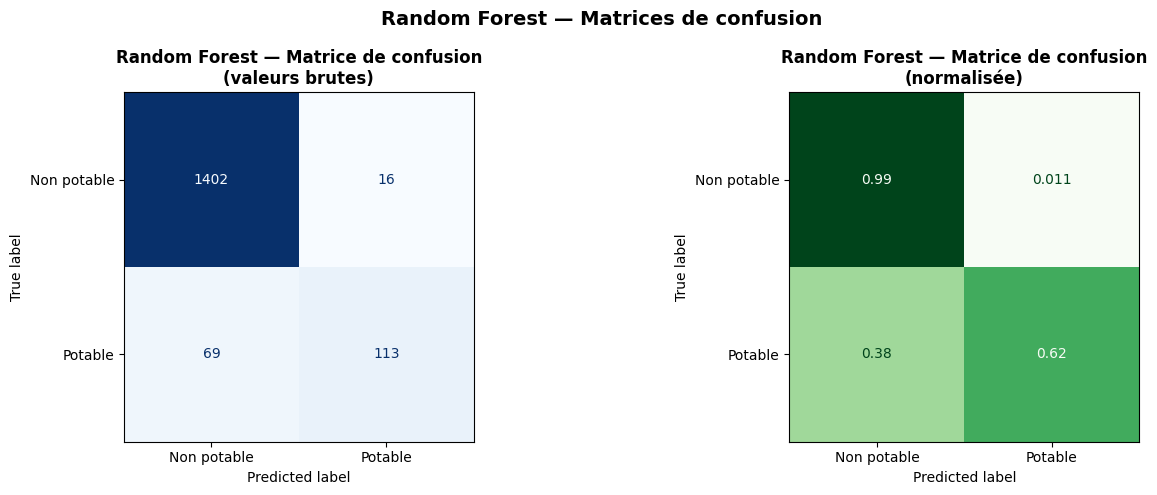

Vrais Négatifs (TN) : 1402 | Faux Positifs (FP) : 16
Faux Négatifs (FN)  : 69 | Vrais Positifs (TP) : 113


In [63]:
# 7.3 — Matrice de confusion RF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice brute
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Non potable', 'Potable'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Random Forest — Matrice de confusion\n(valeurs brutes)', fontsize=12, fontweight='bold')

# Matrice normalisée
cm_rf_norm = confusion_matrix(y_test, y_pred_rf, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_rf_norm, display_labels=['Non potable', 'Potable'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest — Matrice de confusion\n(normalisée)', fontsize=12, fontweight='bold')

plt.suptitle('Random Forest — Matrices de confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f'Vrais Négatifs (TN) : {tn} | Faux Positifs (FP) : {fp}')
print(f'Faux Négatifs (FN)  : {fn} | Vrais Positifs (TP) : {tp}')

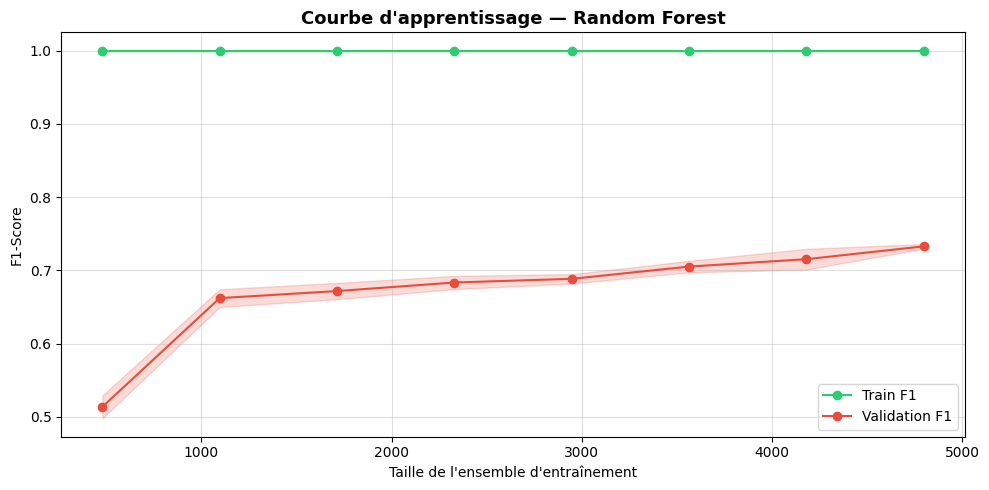

In [64]:
# 7.4 — Courbe d'apprentissage RF
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train_sel, y_train,
    cv=cv, scoring='f1', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#2ecc71', label='Train F1')
plt.fill_between(train_sizes, train_scores.mean(1) - train_scores.std(1),
                 train_scores.mean(1) + train_scores.std(1), alpha=0.2, color='#2ecc71')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#e74c3c', label='Validation F1')
plt.fill_between(train_sizes, val_scores.mean(1) - val_scores.std(1),
                 val_scores.mean(1) + val_scores.std(1), alpha=0.2, color='#e74c3c')
plt.title('Courbe d\'apprentissage — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Taille de l\'ensemble d\'entraînement')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

---
## 🤖 Partie 8 — Modèle 2 : Support Vector Machine (SVM)

### Description du modèle

Le **Support Vector Machine (SVM)** est un algorithme de classification qui cherche l'**hyperplan optimal** séparant les deux classes avec la **marge maximale**.

**Principe fondamental :**
- Les **vecteurs de support** sont les points d'entraînement les plus proches de l'hyperplan de décision.
- L'hyperplan optimal maximise la distance (marge) entre les deux classes.
- Le **noyau (kernel)** permet de projeter les données dans un espace de dimension supérieure pour les rendre linéairement séparables.

```
Classe A (●)         Hyperplan optimal
    ●   ●               │
  ●   ●   ●    ←marge→ │ ←marge→    ■   ■
    ●   ○                │              ■   ■
      (vecteur           │    ○ (vecteur
       support)          │       support)
                               Classe B (■)
```

**Noyaux courants** : linéaire, RBF (Radial Basis Function), polynomial.  
**Hyperparamètres clés** : `C` (régularisation), `kernel`, `gamma` (pour RBF).

In [65]:
# 8.1 — Optimisation des hyperparamètres SVM (CV=4)
print('=== SVM — RECHERCHE DES HYPERPARAMÈTRES OPTIMAUX (CV=4) ===')

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_sel, y_train)

print(f'\n✅ Meilleurs paramètres SVM : {grid_svm.best_params_}')
print(f'   Meilleur F1-score (CV)   : {grid_svm.best_score_:.4f}')

=== SVM — RECHERCHE DES HYPERPARAMÈTRES OPTIMAUX (CV=4) ===
Fitting 4 folds for each of 12 candidates, totalling 48 fits

✅ Meilleurs paramètres SVM : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
   Meilleur F1-score (CV)   : 0.7226


In [66]:
# 8.2 — Évaluation du meilleur modèle SVM
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_sel)
y_proba_svm = best_svm.predict_proba(X_test_sel)[:, 1]

print('=== PERFORMANCES DU SVM (MEILLEURS PARAMS) ===')
print(classification_report(y_test, y_pred_svm, target_names=['Non potable', 'Potable']))

print(f'AUC-ROC : {roc_auc_score(y_test, y_proba_svm):.4f}')

# Validation croisée
cv_scores_svm = cross_val_score(best_svm, X_train_sel, y_train, cv=cv, scoring='f1')
print(f'\nCV F1-scores (4-fold) : {cv_scores_svm.round(4)}')
print(f'Moyenne CV F1         : {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}')

=== PERFORMANCES DU SVM (MEILLEURS PARAMS) ===
              precision    recall  f1-score   support

 Non potable       0.96      0.98      0.97      1418
     Potable       0.79      0.66      0.72       182

    accuracy                           0.94      1600
   macro avg       0.87      0.82      0.84      1600
weighted avg       0.94      0.94      0.94      1600

AUC-ROC : 0.9446

CV F1-scores (4-fold) : [0.7289 0.7251 0.7152 0.7211]
Moyenne CV F1         : 0.7226 ± 0.0051


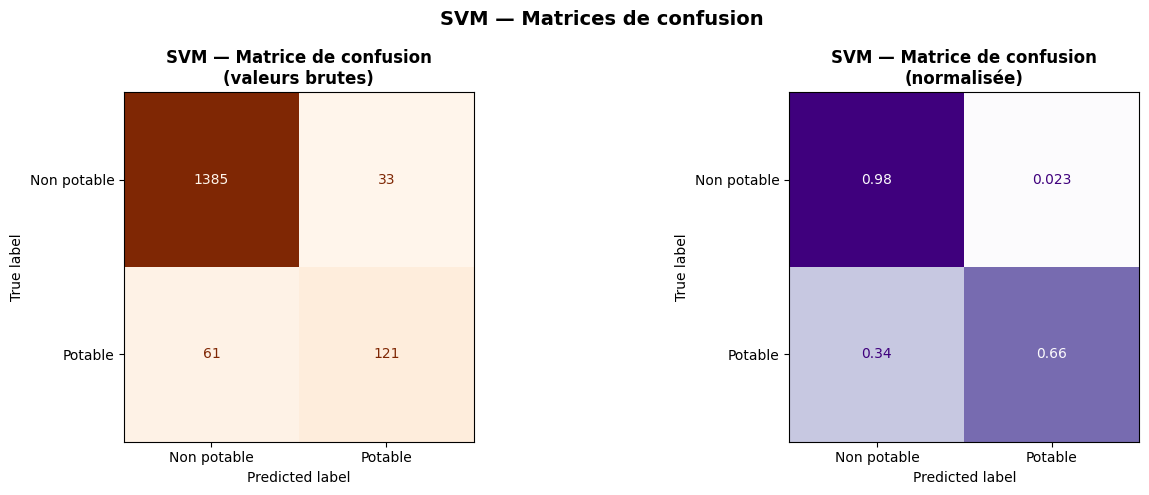

Vrais Négatifs (TN) : 1385 | Faux Positifs (FP) : 33
Faux Négatifs (FN)  : 61 | Vrais Positifs (TP) : 121


In [67]:
# 8.3 — Matrice de confusion SVM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Non potable', 'Potable'])
disp3.plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title('SVM — Matrice de confusion\n(valeurs brutes)', fontsize=12, fontweight='bold')

cm_svm_norm = confusion_matrix(y_test, y_pred_svm, normalize='true')
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm_svm_norm, display_labels=['Non potable', 'Potable'])
disp4.plot(ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title('SVM — Matrice de confusion\n(normalisée)', fontsize=12, fontweight='bold')

plt.suptitle('SVM — Matrices de confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_svm.ravel()
print(f'Vrais Négatifs (TN) : {tn} | Faux Positifs (FP) : {fp}')
print(f'Faux Négatifs (FN)  : {fn} | Vrais Positifs (TP) : {tp}')

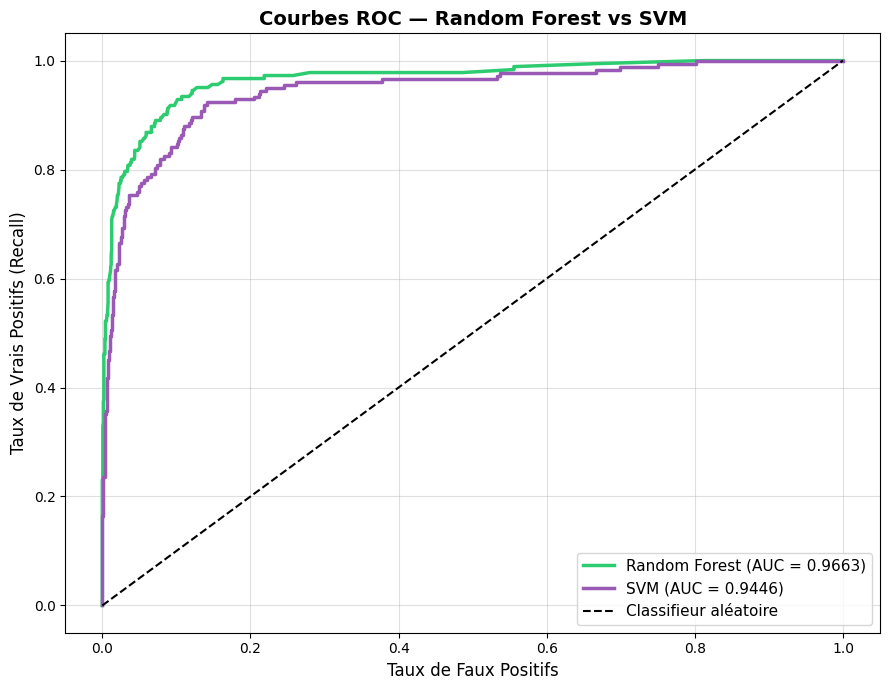

In [68]:
# 8.4 — Courbes ROC comparées
from sklearn.metrics import roc_curve, auc

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(9, 7))
plt.plot(fpr_rf, tpr_rf, lw=2.5, color='#2ecc71',
         label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_svm, tpr_svm, lw=2.5, color='#9b59b6',
         label=f'SVM (AUC = {auc_svm:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Classifieur aléatoire')
plt.xlabel('Taux de Faux Positifs', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Recall)', fontsize=12)
plt.title('Courbes ROC — Random Forest vs SVM', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

---
## 📋 Partie 9 — Tableaux récapitulatifs des performances

In [69]:
# 9.1 — Tableau récapitulatif des métriques
def get_metrics(y_true, y_pred, y_proba, cv_scores, model_name):
    return {
        'Modèle': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'CV F1 Moyen': cv_scores.mean(),
        'CV F1 Std': cv_scores.std()
    }

results = [
    get_metrics(y_test, y_pred_rf,  y_proba_rf,  cv_scores_rf,  '🌳 Random Forest'),
    get_metrics(y_test, y_pred_svm, y_proba_svm, cv_scores_svm, '🤖 SVM'),
]

results_df = pd.DataFrame(results).set_index('Modèle')
print('=== TABLEAU RÉCAPITULATIF DES PERFORMANCES ===')
results_df.round(4).style.highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','AUC-ROC','CV F1 Moyen'],
                                         color='#d5f5e3').format('{:.4f}')

=== TABLEAU RÉCAPITULATIF DES PERFORMANCES ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV F1 Moyen,CV F1 Std
Modèle,,,,,,,
🌳 Random Forest,0.9469,0.8760,0.6209,0.7267,0.9663,0.7336,0.0032
🤖 SVM,0.9412,0.7857,0.6648,0.7202,0.9446,0.7226,0.0051


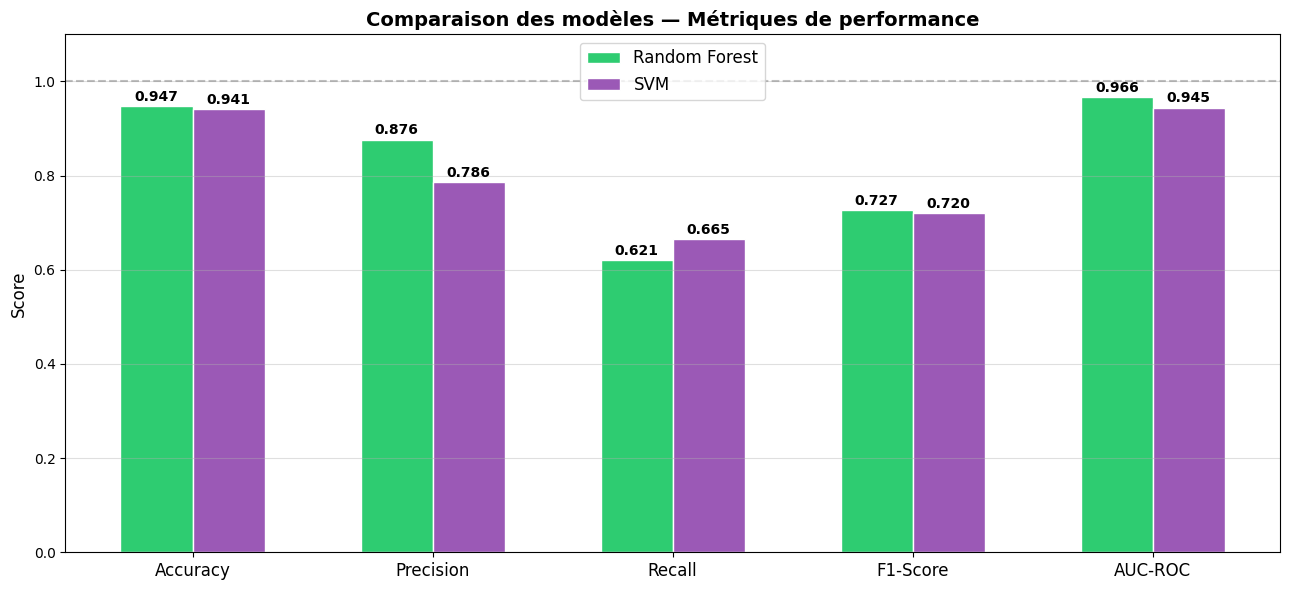

In [70]:
# 9.2 — Visualisation comparative
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
rf_vals  = [results_df.loc['🌳 Random Forest', m] for m in metrics]
svm_vals = [results_df.loc['🤖 SVM', m] for m in metrics]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, svm_vals, width, label='SVM',           color='#9b59b6', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des modèles — Métriques de performance', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [71]:
# 9.3 — Tableau des hyperparamètres optimaux
print('=== HYPERPARAMÈTRES OPTIMAUX ===')
params_summary = pd.DataFrame([
    {'Modèle': '🌳 Random Forest', **grid_rf.best_params_,
     'CV F1': f"{grid_rf.best_score_:.4f}"},
    {'Modèle': '🤖 SVM', **grid_svm.best_params_,
     'CV F1': f"{grid_svm.best_score_:.4f}"}
]).set_index('Modèle').fillna('-')
print(params_summary.to_string())

=== HYPERPARAMÈTRES OPTIMAUX ===
                max_depth max_features min_samples_split n_estimators   CV F1     C  gamma kernel
Modèle                                                                                           
🌳 Random Forest      20.0         sqrt               2.0        200.0  0.7336     -      -      -
🤖 SVM                   -            -                 -            -  0.7226  10.0  scale    rbf


In [72]:
# 9.4 — CV scores détaillés par fold
print('=== VALIDATION CROISÉE (4-FOLD) — DÉTAIL PAR FOLD ===')

cv_detail = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(4)],
    'Random Forest F1': cv_scores_rf.round(4),
    'SVM F1': cv_scores_svm.round(4)
}).set_index('Fold')

cv_detail.loc['Moyenne ± Std'] = [
    f"{cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}",
    f"{cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}"
]
print(cv_detail.to_string())

=== VALIDATION CROISÉE (4-FOLD) — DÉTAIL PAR FOLD ===
              Random Forest F1           SVM F1
Fold                                           
Fold 1                  0.7325           0.7289
Fold 2                   0.729           0.7251
Fold 3                  0.7379           0.7152
Fold 4                  0.7348           0.7211
Moyenne ± Std  0.7336 ± 0.0032  0.7226 ± 0.0051


In [73]:
# 9.5 — Résumé final
print('=' * 60)
print('📊 RÉSUMÉ FINAL')
print('=' * 60)

best_model = results_df['F1-Score'].idxmax()
best_f1    = results_df['F1-Score'].max()
best_auc   = results_df.loc[best_model, 'AUC-ROC']

print(f'\n🏆 MEILLEUR MODÈLE : {best_model}')
print(f'   F1-Score test  : {best_f1:.4f}')
print(f'   AUC-ROC test   : {best_auc:.4f}')

print('\n📌 CONCLUSIONS :')
print(f'  • Dataset : {len(df_clean2):,} échantillons × {len(X.columns)} features')
print(f'  • Features sélectionnées : {K_BEST} (ANOVA F-test)')
print(f'  • Validation croisée : StratifiedKFold (CV=4)')
print(f'  • RF  — Accuracy : {results_df.loc["🌳 Random Forest","Accuracy"]:.4f} | F1 : {results_df.loc["🌳 Random Forest","F1-Score"]:.4f}')
print(f'  • SVM — Accuracy : {results_df.loc["🤖 SVM","Accuracy"]:.4f} | F1 : {results_df.loc["🤖 SVM","F1-Score"]:.4f}')
print('\n✅ Analyse complète terminée')

📊 RÉSUMÉ FINAL

🏆 MEILLEUR MODÈLE : 🌳 Random Forest
   F1-Score test  : 0.7267
   AUC-ROC test   : 0.9663

📌 CONCLUSIONS :
  • Dataset : 7,999 échantillons × 20 features
  • Features sélectionnées : 15 (ANOVA F-test)
  • Validation croisée : StratifiedKFold (CV=4)
  • RF  — Accuracy : 0.9469 | F1 : 0.7267
  • SVM — Accuracy : 0.9413 | F1 : 0.7202

✅ Analyse complète terminée
